[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AnahitShekikyan/ml-with-python-for-high-school-students/blob/main/chapter_03_data_preparation/chapter_3_1_data_cleaning.ipynb)


# Chapter 3: Data Preparation for Machine Learning

Data preparation is the process of getting data ready for machine learning.  
It includes cleaning data, exploring it, handling imbalance, and splitting it for training and testing.

In this chapter, the work is divided into three parts:
- **3.1 Data Cleaning**
- **3.2 Exploratory Data Analysis (EDA)**
- **3.3 Data Balancing and Train-Test Split**

---

# 🧹 Chapter 3.1: Data Cleaning for Machine Learning

Before a machine learning model can learn from data, the data must be checked and cleaned.  
In this notebook, students will learn how to inspect a dataset, find missing values, remove duplicates, handle outliers, and fix inconsistent formatting.

---

## 🎯 Learning Goals

By the end of this notebook, students will be able to:

1. explain why data cleaning matters
2. load a dataset into Python using pandas
3. inspect rows, columns, and data types
4. identify and handle missing values
5. remove duplicate rows
6. handle outliers and unrealistic values
7. standardize inconsistent text formatting
8. save a cleaned dataset for later use

## 3.1.1 Warm-Up

> 🏋️ **Think about it first:**
>
> 1. Have you ever seen a form where someone entered clearly wrong data?
> 2. If a song is missing its genre on Spotify, what are some ways you could handle that?
> 3. Why do you think cleaning data is often described as one of the most time-consuming parts of ML?

**✏️ Your answers here:**

1. 

2. 

3. 

---
## ⚙️ Setup — Import Libraries

In [3]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statistics

---
## 3.1.2 Load & First Look 📥

This dataset contains Spotify tracks from Kaggle.  
Each row represents one song, and the columns include information such as track name, artist, genre, popularity, and audio features like danceability, energy, valence, tempo, and duration.

As with many real-world datasets, it may contain issues that need to be checked and cleaned before machine learning.

### 📋 Dataset Columns

| Column | Description |
|--------|-------------|
| `track_name` | Song title |
| `artists` | Artist name(s) |
| `album_name` | Album the song appears on |
| `track_genre` | Genre category (e.g. pop, rock, hip-hop) |
| `popularity` | Spotify popularity score (0–100) |
| `duration_ms` | Song length in milliseconds |
| `explicit` | Whether the song has explicit lyrics (True/False) |
| `danceability` | How suitable for dancing (0–1) |
| `energy` | Intensity and activity level (0–1) |
| `loudness` | Overall loudness in decibels |
| `valence` | Musical positiveness — how "happy" it sounds (0–1) |
| `tempo` | Beats per minute (BPM) |
| `speechiness` | Presence of spoken words (0–1) |
| `acousticness` | How acoustic the song is (0–1) |
| `instrumentalness` | Likelihood of no vocals (0–1) |

In [ ]:
# load the dataset
df = pd.read_csv("spotify-tracks-dataset.csv")

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Shape: 114000 rows × 22 columns


,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [5]:
# drop unnamed index columns that sometimes appear when a CSV is saved and re-loaded
unnamed_cols = [col for col in df.columns if col.startswith("Unnamed")]
if unnamed_cols:
    df = df.drop(columns=unnamed_cols)
    print(f"Dropped junk columns: {unnamed_cols}")
df.head()

Dropped junk columns: ['Unnamed: 0.1', 'Unnamed: 0']


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [6]:
# get detailed info about columns, data types, and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

In [7]:
# statistical summary — look for anything suspicious!
df.describe(include="all")

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
count,114000,113999,113999,113999,114000.000000,1.140000e+05,114000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000
unique,89741,31437,46589,73608,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,114
top,6S3JlDAGk3uu3NtZbPnuhS,The Beatles,Alternative Christmas 2022,Run Rudolph Run,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,acoustic
freq,9,279,195,151,NaN,NaN,104253,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000
mean,NaN,NaN,NaN,NaN,33.238535,2.280292e+05,NaN,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035,NaN
std,NaN,NaN,NaN,NaN,22.305078,1.072977e+05,NaN,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621,NaN
min,NaN,NaN,NaN,NaN,0.000000,0.000000e+00,NaN,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,17.000000,1.740660e+05,NaN,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000,NaN
50%,NaN,NaN,NaN,NaN,35.000000,2.129060e+05,NaN,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000,NaN
75%,NaN,NaN,NaN,NaN,50.000000,2.615060e+05,NaN,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000,NaN


> 🏋️ **Practice 1 — Spot the Problems:**
>
> Look at `.describe()` carefully. Can you spot anything suspicious?
>
> 1. Are there any columns with missing values?
> 2. Do any numeric columns seem to have unrealistic minimum or maximum values?
> 3. Are there any columns that may need cleaning before machine learning?


**✏️ Your answers here:**

1. 

2. 

3. 

---
## 3.1.3 Missing Values 🕳️

Missing values appear as `NaN` in pandas. Most machine learning models do not work well with missing values, so missing data usually needs to be handled before modeling.

### Three common strategies

| Strategy | When to use |
|----------|-------------|
| **Fill with median** | Numeric columns — median is safer when outliers exist |
| **Fill with mode** | Categorical columns — use the most common value |
| **Drop rows** | When only a few rows are missing and enough data remains |

In [8]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()} out of {df.size} values")

Missing values per column:
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Total missing: 3 out of 2280000 values


In [9]:
# fill numeric columns with median
numeric_cols = df.select_dtypes(include=["number"]).columns

for col in numeric_cols:
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"{col}: filled {missing_count} missing value(s) with median = {median_val:.2f}")

In [10]:
# fill text columns with mode if missing values exist
text_cols = df.select_dtypes(include=["object"]).columns

for col in text_cols:
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"{col}: filled {missing_count} missing value(s) with mode = {mode_val}")

artists: filled 1 missing value(s) with mode = The Beatles
album_name: filled 1 missing value(s) with mode = Alternative Christmas 2022
track_name: filled 1 missing value(s) with mode = Run Rudolph Run


In [11]:
print("Missing values remaining:")
print(df.isnull().sum().sum())

Missing values remaining:
0


> 🏋️ **Practice 2:**
>
> We used **median** to fill missing values instead of **mean**.
>
> Run the cell below to see why. When a column has extreme values, which is more reliable — mean or median?

In [12]:
# quick experiment: compare mean vs median on a column with extreme values
test_data = [100, 105, 98, 102, 110, 99, -999, 101, 103, 107]

print(f"Data: {test_data}")
print(f"Mean:   {sum(test_data)/len(test_data):.1f}")
print(f"Median: {statistics.median(test_data):.1f}")

print("\nWhich is better for filling missing values when extreme values exist?")

Data: [100, 105, 98, 102, 110, 99, -999, 101, 103, 107]
Mean:   -7.4
Median: 101.5

Which is better for filling missing values when extreme values exist?


**✏️ Your answer here:**



---
## 3.1.4 Duplicate Rows 

Duplicate rows are exact copies of a row that appears more than once. This might happen when:
- the same song was collected twice
- data from multiple sources was merged
- a record was entered more than once

In [13]:
num_dups = df.duplicated().sum()
print(f"Duplicate rows found: {num_dups}")

Duplicate rows found: 450


In [14]:
if num_dups > 0:
    print("A few duplicate rows:")
    print(df[df.duplicated()].head())

A few duplicate rows:
                    track_id                 artists          album_name  \
1925  0CDucx9lKxuCZplLXUz0iX  Buena Onda Reggae Club             Disco 2   
2155  2aibwv5hGXSgw7Yru8IYTO   Red Hot Chili Peppers    Stadium Arcadium   
3738  7mULVp0DJrI2Nd6GesLvxn            Joy Division  Timeless Rock Hits   
4648  6d3RIvHfVkoOtW1WHXmbX3         Little Symphony            Serenity   
5769  481beimUiUnMUzSbOAFcUT            SUPER BEAVER       突破口 / 自慢になりたい   

                   track_name  popularity  duration_ms  explicit  \
1925         Song for Rollins          16       219346     False   
2155            Snow (Hey Oh)          80       334666     False   
3738  Love Will Tear Us Apart           0       204621     False   
4648                   Margot          27        45714     False   
5769                      突破口          54       255080     False   

      danceability  energy  key  loudness  mode  speechiness  acousticness  \
1925         0.841   0.577    0   

In [15]:
before = len(df)
df = df.drop_duplicates()
after = len(df)

print(f"Removed {before - after} duplicate row(s). {before} → {after} rows")

Removed 450 duplicate row(s). 114000 → 113550 rows


> 🏋️ **Practice 3:** Can you think of a real-life situation where duplicate data might sneak into a dataset? How could you prevent it from happening in the first place?

**✏️ Your answer here:**



## 3.1.5 Outliers & Unrealistic Values

Some values in a dataset may be unrealistic or fall outside expected ranges.  
For example, popularity should stay between 0 and 100, duration should not be 0, and tempo should stay within a realistic musical range.

In this section, we first use boxplots to **identify possible outliers**, then use **domain knowledge** to define valid ranges and **clip** extreme values to those ranges.

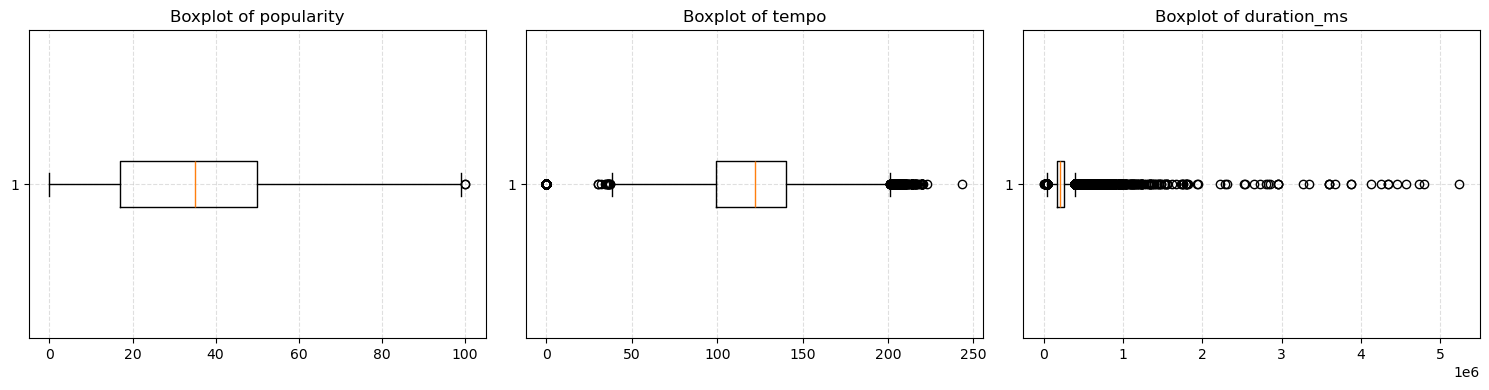

In [16]:
# visualize selected numeric columns before fixing
cols_to_plot = [col for col in ["popularity", "tempo", "duration_ms"] if col in df.columns]

fig, axes = plt.subplots(1, len(cols_to_plot), figsize=(5 * len(cols_to_plot), 4))

if len(cols_to_plot) == 1:
    axes = [axes]

for ax, col in zip(axes, cols_to_plot):
    ax.boxplot(df[col].dropna(), vert=False)
    ax.set_title(f"Boxplot of {col}")
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [17]:
# define valid ranges based on domain knowledge
valid_ranges = {
    "popularity": (0, 100),                 # Spotify score 0-100
    "tempo": (40, 250),                     # BPM: very slow to very fast songs
    "duration_ms": (30_000, 600_000),       # 30s to 10min in milliseconds
    "danceability": (0, 1),
    "energy": (0, 1),
    "valence": (0, 1),
}

for col, (lo, hi) in valid_ranges.items():
    if col in df.columns:
        bad_count = ((df[col] < lo) | (df[col] > hi)).sum()
        df[col] = df[col].clip(lower=lo, upper=hi)
        print(f"{col}: fixed {bad_count} value(s) outside [{lo}, {hi}]")

popularity: fixed 0 value(s) outside [0, 100]
tempo: fixed 174 value(s) outside [40, 250]
duration_ms: fixed 615 value(s) outside [30000, 600000]
danceability: fixed 0 value(s) outside [0, 1]
energy: fixed 0 value(s) outside [0, 1]
valence: fixed 0 value(s) outside [0, 1]


> 🏋️ **Practice 4:**
>
> 1. Which column had the most obvious outliers?
> 2. Why might deleting rows be risky?
> 3. How did we decide what a realistic range for `tempo` should be?


**✏️ Your answers here:**

1. 

2. 

3. 

---
## 3.1.6 Fixing Inconsistent Text

Real datasets often contain inconsistent formatting.

For example:
- the same genre may appear as `"Pop"`, `"pop"`, or `"POP"`
- the `explicit` column may contain values such as `True`, `False`, `"Yes"`, `"No"`, `1`, or `0`

Before machine learning, these values should be made consistent.

In [18]:
# standardize track_genre if it exists
if "track_genre" in df.columns:
    print("BEFORE — sample genre values:")
    print(sorted(df["track_genre"].astype(str).dropna().unique())[:15])

    df["track_genre"] = df["track_genre"].astype(str).str.strip().str.title()

    print("\nAFTER — sample genre values:")
    print(sorted(df["track_genre"].dropna().unique())[:15])

BEFORE — sample genre values:
['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient', 'anime', 'black-metal', 'bluegrass', 'blues', 'brazil', 'breakbeat', 'british', 'cantopop', 'chicago-house', 'children']

AFTER — sample genre values:
['Acoustic', 'Afrobeat', 'Alt-Rock', 'Alternative', 'Ambient', 'Anime', 'Black-Metal', 'Bluegrass', 'Blues', 'Brazil', 'Breakbeat', 'British', 'Cantopop', 'Chicago-House', 'Children']


In [19]:
# standardize explicit column if it exists
def standardize_explicit(val):
    return str(val).strip().lower() in ["true", "yes", "1"]

if "explicit" in df.columns:
    print("BEFORE — explicit values:")
    print(df["explicit"].value_counts(dropna=False))

    df["explicit"] = df["explicit"].apply(standardize_explicit)

    print("\nAFTER — explicit values:")
    print(df["explicit"].value_counts(dropna=False))

BEFORE — explicit values:
explicit
False    103832
True       9718
Name: count, dtype: int64

AFTER — explicit values:
explicit
False    103832
True       9718
Name: count, dtype: int64


> 🏋️ **Practice 5:**
>
> Can you think of another real-world column that might have inconsistent formatting?  
> For example, what problems might happen with a `country` column in a global survey?

**✏️ Your answer here:**

## 3.1.7 Save the Cleaned Dataset 💾

We will save the cleaned version of the dataset so it can be used in the next notebooks.

In [20]:
df.to_csv("spotify_tracks_clean.csv", index=False)

print("Clean dataset saved as: spotify_tracks_clean.csv")
print(f"Final shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Missing values remaining: {df.isnull().sum().sum()}")
print(f"Duplicate rows remaining: {df.duplicated().sum()}")

df.head()

Clean dataset saved as: spotify_tracks_clean.csv
Final shape: 113550 rows × 20 columns
Missing values remaining: 0
Duplicate rows remaining: 0


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,Acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,Acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,Acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,Acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,Acoustic


> 🏋️ **Practice 6:** 
> 
> Can you think of other real-world columns that might have inconsistent formatting like this?  
> For example, what might happen with a `country` column in a global survey?

**✏️ Your answer here:**



---
## 🎉 Chapter 3.1 Summary

| Problem | How We Fixed It |
|---------|------------------|
| Missing values | Filled numeric columns with **median** and text columns with **mode** |
| Duplicate rows | Removed with `.drop_duplicates()` |
| Unrealistic values | Clipped to valid ranges using domain knowledge |
| Inconsistent text | Standardized with `.str.strip()` and `.str.title()` |
| Mixed explicit values | Converted to a consistent `True` / `False` format |

---

### 🏆 Chapter Challenge

The `duration_ms` column stores song length in **milliseconds**. Add a new column called `duration_min` that converts this to **minutes**. Then find:

1. the average song length in minutes
2. the longest and shortest songs in the dataset
3. how many songs are longer than 4 minutes

In [ ]:
# 🏆 Challenge — your code here!
